# Projet ML 2026 - Notebook Pipeline



- Mode possible: classification (`Categorie`) ou regression (`Prix_Revente`)
- Dataset: `dataset_ProjetML_2026.csv`
- Objectif: comparer des modeles baseline puis visualiser/exporter les resultats

## 1) Installer et importer les dependances

In [1]:
# Decommenter si necessaire
# %pip install pandas numpy scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

sns.set_theme(style="whitegrid")

## 2) Definir les parametres du notebook

In [2]:
DATA_PATH = Path("dataset_ProjetML_2026.csv")
TASK = "classification"   # "classification" ou "regression"
TARGET = "Categorie"      # classification: "Categorie" ; regression: "Prix_Revente"

# Exigence cahier des charges: split fixe 70/15/15
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42
USE_TEXT_FEATURE = True

NA_VALUES = ["", " ", "NA", "N/A", "null", "None", "non mesure", "non mesure kg"]
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Task={TASK}, Target={TARGET}, Data={DATA_PATH}")
print(f"Ratios -> train={TRAIN_RATIO}, val={VAL_RATIO}, test={TEST_RATIO}")

Task=classification, Target=Categorie, Data=dataset_ProjetML_2026.csv
Ratios -> train=0.7, val=0.15, test=0.15


## 3) Charger les donnees d'entree

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Fichier introuvable: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, na_values=NA_VALUES)
print("Shape:", df.shape)
print("Colonnes:", list(df.columns))

display(df.head(3))
print("\nValeurs manquantes (%)")
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_%"))

Shape: (10500, 9)
Colonnes: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte']


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...



Valeurs manquantes (%)


,missing_%
Opacite,9.857143
Poids,9.800000
Conductivite,9.685714
Rigidite,5.314286
Volume,5.142857
Prix_Revente,5.104762
Source,5.104762
Categorie,4.895238
Rapport_Collecte,0.000000


In [5]:
# Correlation numerique (pour l'analyse exploratoire)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matrice de correlation")
    plt.tight_layout()
    plt.show()

NameError: name 'num_cols' is not defined

Distribution de la cible:


,count
Categorie,
Plastique,2795
Verre,2586
Papier,2318
Métal,2287
NaN,514


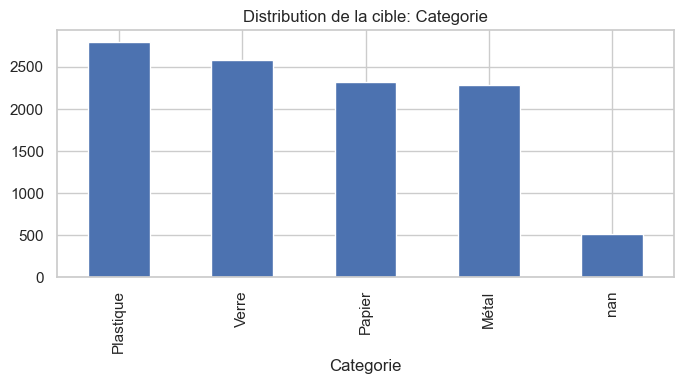

In [6]:
# Distribution de la cible (utile pour justifier le choix des metriques)
if TARGET in df.columns:
    print("Distribution de la cible:")
    display(df[TARGET].value_counts(dropna=False).to_frame("count"))

    plt.figure(figsize=(7, 4))
    df[TARGET].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribution de la cible: {TARGET}")
    plt.tight_layout()
    plt.show()

In [7]:
# Resume statistique des variables numeriques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    display(df[num_cols].describe().T)
else:
    print("Aucune colonne numerique detectee.")

,count,mean,std,min,25%,50%,75%,max
Poids,9471.0,77.796501,127.847433,-99.000000,19.751538,39.193029,130.497561,2334.218831
Volume,9960.0,144.408079,136.384216,-26.807712,44.436897,88.084217,240.200023,554.106969
Conductivite,9483.0,0.207674,0.378934,0.000000,0.000000,0.000000,0.000000,0.999375
Opacite,9465.0,1.160388,5.492723,0.000037,0.196410,0.553484,1.000000,55.000000
Rigidite,9942.0,5.886643,3.087225,1.000000,3.000000,5.000000,9.000000,10.000000
Prix_Revente,9964.0,58.587857,720.059089,-50.000000,1.393623,4.135356,6.781634,9999.000000


## 3.1) Controle qualite des donnees (EDA de base)

## 4) Creer des fonctions utilitaires reutilisables

In [8]:
def split_train_val_test(X, y, stratify=False):
    # 1) Separation train (70%) vs temporaire (30%)
    strat = y if stratify else None
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X,
        y,
        test_size=(1 - TRAIN_RATIO),
        random_state=RANDOM_STATE,
        stratify=strat,
    )

    # 2) Separation temporaire en val/test (15%/15%)
    strat_tmp = y_tmp if stratify else None
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp,
        y_tmp,
        test_size=0.5,
        random_state=RANDOM_STATE,
        stratify=strat_tmp,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


def build_preprocessor(df_input: pd.DataFrame, target_col: str, use_text: bool = True):
    text_candidates = ["Rapport_Collecte", "Rapport"]
    text_col = None
    if use_text:
        for col in text_candidates:
            if col in df_input.columns:
                text_col = col
                break

    feature_cols = [c for c in df_input.columns if c != target_col]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_input[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols and c != text_col]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformers = [
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),
    ]

    if text_col:
        text_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="")),
            ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
            ("tfidf", TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
        ])
        transformers.append(("txt", text_pipe, [text_col]))

    return ColumnTransformer(transformers=transformers)

In [9]:
def train_and_evaluate_regression(df_input: pd.DataFrame, target_col: str):
    data = df_input.dropna(subset=[target_col]).copy()
    X = data.drop(columns=[target_col])
    y = pd.to_numeric(data[target_col], errors="coerce")

    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask]
    data = data.loc[mask]

    preprocessor = build_preprocessor(data, target_col, USE_TEXT_FEATURE)

    models = {
        "linreg": LinearRegression(),
        "rf_reg": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    }

    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=False)

    rows = []
    artifacts = {}

    for name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)

        pred_val = pipe.predict(X_val)
        pred_test = pipe.predict(X_test)

        rmse_val = float(np.sqrt(mean_squared_error(y_val, pred_val)))
        mae_test = mean_absolute_error(y_test, pred_test)
        rmse_test = float(np.sqrt(mean_squared_error(y_test, pred_test)))
        r2_test = r2_score(y_test, pred_test)

        rows.append({
            "model": name,
            "rmse_val": rmse_val,
            "MAE_test": mae_test,
            "RMSE_test": rmse_test,
            "R2_test": r2_test,
        })
        artifacts[name] = {
            "pipeline": pipe,
            "y_test": y_test,
            "pred": pred_test,
        }

    results = pd.DataFrame(rows).sort_values("rmse_val", ascending=True).reset_index(drop=True)
    return results, artifacts

### 4.2) Fonction d'entrainement et d'evaluation: regression

In [10]:
def train_and_evaluate_classification(df_input: pd.DataFrame, target_col: str):
    data = df_input.dropna(subset=[target_col]).copy()
    X = data.drop(columns=[target_col])
    y = data[target_col].astype(str)

    preprocessor = build_preprocessor(data, target_col, USE_TEXT_FEATURE)

    models = {
        "logreg": LogisticRegression(max_iter=2000),
        "rf": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    }

    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=True)

    rows = []
    artifacts = {}

    for name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)

        pred_val = pipe.predict(X_val)
        pred_test = pipe.predict(X_test)

        f1_val = f1_score(y_val, pred_val, average="macro")
        f1_test = f1_score(y_test, pred_test, average="macro")
        acc_test = accuracy_score(y_test, pred_test)

        rows.append({
            "model": name,
            "f1_val": f1_val,
            "accuracy_test": acc_test,
            "f1_macro_test": f1_test,
        })
        artifacts[name] = {
            "pipeline": pipe,
            "y_test": y_test,
            "pred": pred_test,
            "confusion": confusion_matrix(y_test, pred_test),
            "report": classification_report(y_test, pred_test),
        }

    results = pd.DataFrame(rows).sort_values("f1_val", ascending=False).reset_index(drop=True)
    return results, artifacts

### 4.1) Fonction d'entrainement et d'evaluation: classification

## 5) Executer le pipeline principal par etapes

In [11]:
if TARGET not in df.columns:
    raise ValueError(f"La cible '{TARGET}' est absente du dataset.")

if TASK not in {"classification", "regression"}:
    raise ValueError("TASK doit etre 'classification' ou 'regression'.")

print("Execution prete.")
print(f"TASK={TASK} | TARGET={TARGET}")

Execution prete.
TASK=classification | TARGET=Categorie


In [12]:
if TASK == "classification":
    results_df, artifacts = train_and_evaluate_classification(df, TARGET)
else:
    results_df, artifacts = train_and_evaluate_regression(df, TARGET)

best_model_name = results_df.iloc[0]["model"]
best_artifact = artifacts[best_model_name]

print(f"Meilleur modele: {best_model_name}")
display(results_df)

Meilleur modele: rf


,model,f1_val,accuracy_test,f1_macro_test
0,rf,1.000000,1.000000,1.000000
1,logreg,0.998057,0.997997,0.998055


## 6) Afficher les resultats intermediaires

In [13]:
if TASK == "classification":
    print("Classification report du meilleur modele:\n")
    print(best_artifact["report"])
    cm_df = pd.DataFrame(best_artifact["confusion"])
    display(cm_df)
else:
    y_true = pd.Series(best_artifact["y_test"]).reset_index(drop=True)
    y_pred = pd.Series(best_artifact["pred"]).reset_index(drop=True)
    control_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    control_df["abs_error"] = (control_df["y_true"] - control_df["y_pred"]).abs()
    display(control_df.head(10))
    print("Erreur absolue moyenne (controle):", control_df["abs_error"].mean())

Classification report du meilleur modele:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



,0,1,2,3
0,343,0,0,0
1,0,348,0,0
2,0,0,419,0
3,0,0,0,388


## 7) Visualiser les resultats finaux

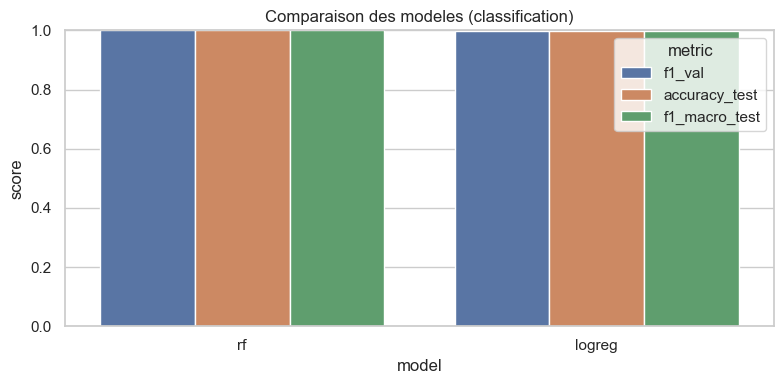

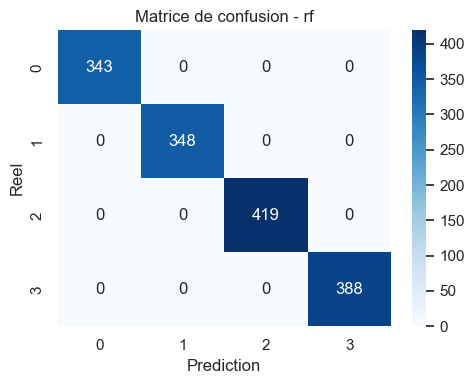

In [14]:
plt.figure(figsize=(8, 4))
if TASK == "classification":
    plot_df = results_df.melt(
        id_vars="model",
        value_vars=["f1_val", "accuracy_test", "f1_macro_test"],
        var_name="metric",
        value_name="score",
    )
    sns.barplot(data=plot_df, x="model", y="score", hue="metric")
    plt.ylim(0, 1)
    plt.title("Comparaison des modeles (classification)")
else:
    plot_df = results_df.melt(
        id_vars="model",
        value_vars=["rmse_val", "MAE_test", "RMSE_test", "R2_test"],
        var_name="metric",
        value_name="value",
    )
    sns.barplot(data=plot_df, x="model", y="value", hue="metric")
    plt.title("Comparaison des modeles (regression)")

plt.tight_layout()
plt.show()

if TASK == "classification":
    plt.figure(figsize=(5, 4))
    sns.heatmap(best_artifact["confusion"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matrice de confusion - {best_model_name}")
    plt.xlabel("Prediction")
    plt.ylabel("Reel")
    plt.tight_layout()
    plt.show()
else:
    y_true = np.array(best_artifact["y_test"])
    y_pred = np.array(best_artifact["pred"])
    plt.figure(figsize=(5, 5))
    sns.scatterplot(x=y_true, y=y_pred, s=18)
    min_v, max_v = y_true.min(), y_true.max()
    plt.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--")
    plt.title(f"Reel vs Pred - {best_model_name}")
    plt.xlabel("Valeur reelle")
    plt.ylabel("Valeur predite")
    plt.tight_layout()
    plt.show()

## 8) Exporter les sorties (fichiers/rapports)

In [15]:
metrics_path = OUTPUT_DIR / f"metrics_{TASK}_{TARGET}.csv"
results_df.to_csv(metrics_path, index=False)
print("Metrics exportees:", metrics_path)

if TASK == "classification":
    report_path = OUTPUT_DIR / f"classification_report_{best_model_name}.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(best_artifact["report"])
    print("Rapport exporte:", report_path)

plot_path = OUTPUT_DIR / f"plot_resume_{TASK}_{TARGET}.png"
plt.figure(figsize=(7, 4))
if TASK == "classification":
    sns.barplot(
        data=results_df.melt(
            id_vars="model",
            value_vars=["f1_val", "accuracy_test", "f1_macro_test"],
            var_name="metric",
            value_name="score",
        ),
        x="model",
        y="score",
        hue="metric",
    )
    plt.ylim(0, 1)
else:
    sns.barplot(
        data=results_df.melt(
            id_vars="model",
            value_vars=["rmse_val", "MAE_test", "RMSE_test", "R2_test"],
            var_name="metric",
            value_name="value",
        ),
        x="model",
        y="value",
        hue="metric",
    )

plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.close()
print("Graphique exporte:", plot_path)

Metrics exportees: outputs\metrics_classification_Categorie.csv
Rapport exporte: outputs\classification_report_rf.txt
Graphique exporte: outputs\plot_resume_classification_Categorie.png


## 9) Comparaison des strategies d'imputation (Mediane vs KNN vs Iterative)

Objectif: comparer plusieurs strategies d'imputation numerique sur la partie supervisee.

In [16]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer


def compare_imputers(df_input: pd.DataFrame, target_col: str):
    data = df_input.dropna(subset=[target_col]).copy()
    X = data.drop(columns=[target_col])
    y = data[target_col].astype(str) if TASK == "classification" else pd.to_numeric(data[target_col], errors="coerce")

    if TASK == "regression":
        mask = y.notna()
        X = X.loc[mask]
        y = y.loc[mask]
        data = data.loc[mask]

    imputers = {
        "median": SimpleImputer(strategy="median"),
        "knn": KNNImputer(n_neighbors=5),
        "iterative": IterativeImputer(random_state=RANDOM_STATE, max_iter=10),
    }

    rows = []
    for imputer_name, imputer in imputers.items():
        text_candidates = ["Rapport_Collecte", "Rapport"]
        text_col = None
        if USE_TEXT_FEATURE:
            for col in text_candidates:
                if col in data.columns:
                    text_col = col
                    break

        feature_cols = [c for c in data.columns if c != target_col]
        numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(data[c])]
        categorical_cols = [c for c in feature_cols if c not in numeric_cols and c != text_col]

        num_pipe = Pipeline([
            ("imputer", imputer),
            ("scaler", StandardScaler()),
        ])
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])

        transformers = [
            ("num", num_pipe, numeric_cols),
            ("cat", cat_pipe, categorical_cols),
        ]

        if text_col:
            text_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="")),
                ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
                ("tfidf", TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
            ])
            transformers.append(("txt", text_pipe, [text_col]))

        preprocessor = ColumnTransformer(transformers=transformers)

        if TASK == "classification":
            model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
            X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=True)
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            pipe.fit(X_train, y_train)
            pred_val = pipe.predict(X_val)
            pred_test = pipe.predict(X_test)
            rows.append({
                "imputer": imputer_name,
                "f1_val": f1_score(y_val, pred_val, average="macro"),
                "f1_test": f1_score(y_test, pred_test, average="macro"),
            })
        else:
            model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
            X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=False)
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            pipe.fit(X_train, y_train)
            pred_val = pipe.predict(X_val)
            pred_test = pipe.predict(X_test)
            rows.append({
                "imputer": imputer_name,
                "rmse_val": float(np.sqrt(mean_squared_error(y_val, pred_val))),
                "rmse_test": float(np.sqrt(mean_squared_error(y_test, pred_test))),
            })

    return pd.DataFrame(rows)

imputation_results = compare_imputers(df, TARGET)
display(imputation_results)

,imputer,f1_val,f1_test
0,median,1.0,1.0
1,knn,1.0,1.0
2,iterative,1.0,1.0


## 10) Detection et traitement des outliers

Objectif: quantifier les outliers puis appliquer un caping (winsorization) simple sur les variables numeriques.

,feature,outlier_rate_%,low,high
2,Conductivite,20.952381,0.000000,0.000000
5,Prix_Revente,16.514286,-6.688393,14.863650
3,Opacite,0.923810,-1.008975,2.205385
0,Poids,0.580952,-146.367497,296.616596
1,Volume,0.114286,-249.207793,533.844712
4,Rigidite,0.000000,-6.000000,18.000000


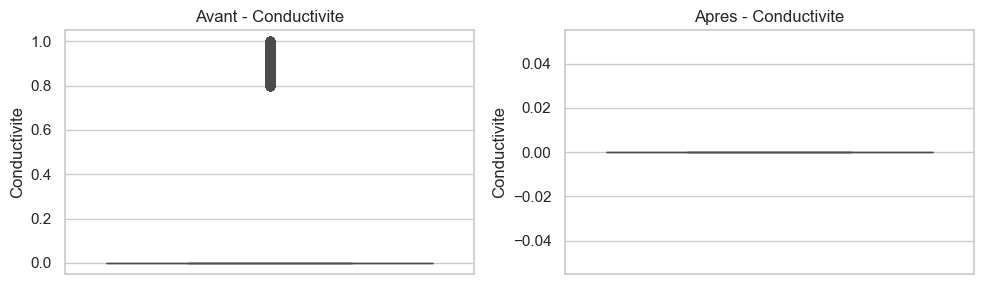

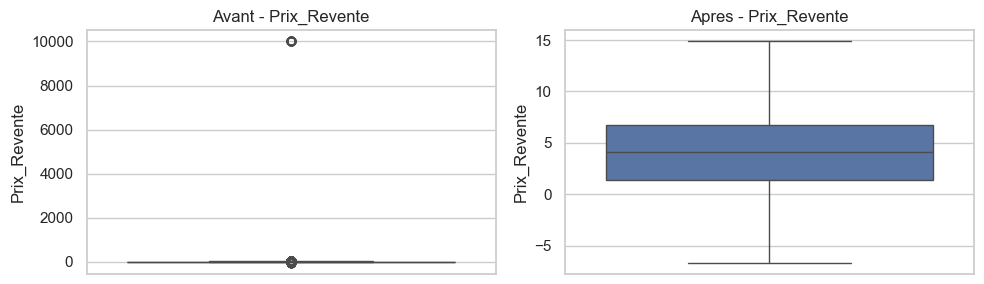

In [17]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()


def iqr_outlier_report(df_input: pd.DataFrame, cols):
    rows = []
    for c in cols:
        s = df_input[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out_rate = ((df_input[c] < low) | (df_input[c] > high)).mean() * 100
        rows.append({"feature": c, "outlier_rate_%": out_rate, "low": low, "high": high})
    return pd.DataFrame(rows).sort_values("outlier_rate_%", ascending=False)

outlier_report = iqr_outlier_report(df, num_cols)
display(outlier_report)


def winsorize_iqr(df_input: pd.DataFrame, cols):
    out = df_input.copy()
    for c in cols:
        s = out[c]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = s.clip(lower=low, upper=high)
    return out

df_outlier_capped = winsorize_iqr(df, num_cols)

# Visualisation rapide: top 2 variables les plus outliers
for c in outlier_report.head(2)["feature"].tolist():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.boxplot(y=df[c], ax=axes[0])
    axes[0].set_title(f"Avant - {c}")
    sns.boxplot(y=df_outlier_capped[c], ax=axes[1])
    axes[1].set_title(f"Apres - {c}")
    plt.tight_layout()
    plt.show()

## 11) Clustering non supervise (Elbow + PCA)

Objectif: ignorer les labels et segmenter les dechets pour decouvrir des sous-groupes.

,k,inertia,silhouette
0,2,44321.931580,0.515851
1,3,32308.994311,0.665058
2,4,22011.955788,0.686795
3,5,11741.114087,0.716427
4,6,6068.765336,0.728111
5,7,5014.691690,0.550988
6,8,4298.416330,0.501544
7,9,4021.877712,0.429673
8,10,3497.354337,0.482934


k retenu (silhouette max): 6


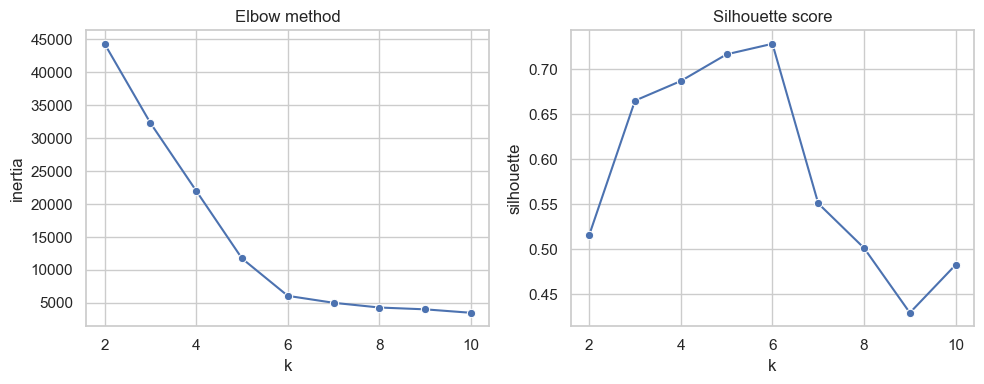

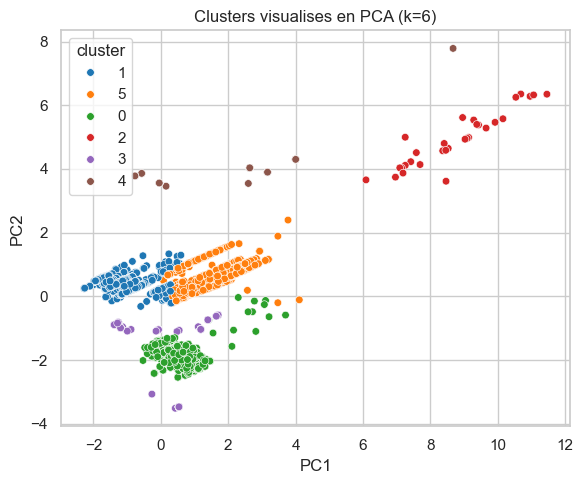

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cluster = df[cluster_num_cols].copy()
X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))
X_cluster = StandardScaler().fit_transform(X_cluster)

ks = list(range(2, 11))
inertias = []
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

elbow_df = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": sil_scores})
display(elbow_df)

best_k = int(elbow_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("k retenu (silhouette max):", best_k)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.lineplot(data=elbow_df, x="k", y="inertia", marker="o")
plt.title("Elbow method")
plt.subplot(1, 2, 2)
sns.lineplot(data=elbow_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette score")
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels.astype(str),
})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", s=30, palette="tab10")
plt.title(f"Clusters visualises en PCA (k={best_k})")
plt.tight_layout()
plt.show()

## 12) Comparaison NLP (BoW, TF-IDF, Word2Vec, FastText)

Objectif: comparer plusieurs representations textuelles pour predire la categorie a partir de la description.

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC

text_col = "Rapport_Collecte" if "Rapport_Collecte" in df.columns else ("Rapport" if "Rapport" in df.columns else None)
if text_col is None:
    raise ValueError("Aucune colonne texte trouvee (Rapport_Collecte ou Rapport).")

if "Categorie" not in df.columns:
    raise ValueError("La colonne Categorie est necessaire pour la comparaison NLP.")

nlp_data = df[[text_col, "Categorie"]].dropna().copy()
X_text = nlp_data[text_col].astype(str)
y_text = nlp_data["Categorie"].astype(str)

X_train_t, X_val_t, X_test_t, y_train_t, y_val_t, y_test_t = split_train_val_test(X_text, y_text, stratify=True)

nlp_rows = []

# 1) BoW + LinearSVC
bow_pipe = Pipeline([
    ("vect", CountVectorizer(max_features=8000, ngram_range=(1, 2))),
    ("clf", LinearSVC()),
])
bow_pipe.fit(X_train_t, y_train_t)
pred_val = bow_pipe.predict(X_val_t)
pred_test = bow_pipe.predict(X_test_t)
nlp_rows.append({
    "method": "BoW+LinearSVC",
    "f1_val": f1_score(y_val_t, pred_val, average="macro"),
    "f1_test": f1_score(y_test_t, pred_test, average="macro"),
})

# 2) TF-IDF + LinearSVC
tfidf_pipe = Pipeline([
    ("vect", TfidfVectorizer(max_features=8000, ngram_range=(1, 2))),
    ("clf", LinearSVC()),
])
tfidf_pipe.fit(X_train_t, y_train_t)
pred_val = tfidf_pipe.predict(X_val_t)
pred_test = tfidf_pipe.predict(X_test_t)
nlp_rows.append({
    "method": "TFIDF+LinearSVC",
    "f1_val": f1_score(y_val_t, pred_val, average="macro"),
    "f1_test": f1_score(y_test_t, pred_test, average="macro"),
})

# 3) Word2Vec/FastText avec fallback si gensim absent
try:
    from gensim.utils import simple_preprocess
    from gensim.models import Word2Vec, FastText

    train_tokens = [simple_preprocess(t) for t in X_train_t.tolist()]
    val_tokens = [simple_preprocess(t) for t in X_val_t.tolist()]
    test_tokens = [simple_preprocess(t) for t in X_test_t.tolist()]

    def avg_embed(tokens_list, model, dim):
        out = []
        for toks in tokens_list:
            vecs = [model.wv[w] for w in toks if w in model.wv]
            out.append(np.mean(vecs, axis=0) if vecs else np.zeros(dim))
        return np.vstack(out)

    w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, workers=1, seed=RANDOM_STATE)
    Xtr_w2v = avg_embed(train_tokens, w2v, 100)
    Xva_w2v = avg_embed(val_tokens, w2v, 100)
    Xte_w2v = avg_embed(test_tokens, w2v, 100)

    clf_w2v = LogisticRegression(max_iter=2000)
    clf_w2v.fit(Xtr_w2v, y_train_t)
    pred_val = clf_w2v.predict(Xva_w2v)
    pred_test = clf_w2v.predict(Xte_w2v)
    nlp_rows.append({
        "method": "Word2Vec+LogReg",
        "f1_val": f1_score(y_val_t, pred_val, average="macro"),
        "f1_test": f1_score(y_test_t, pred_test, average="macro"),
    })

    ft = FastText(sentences=train_tokens, vector_size=100, window=5, min_count=2, workers=1, seed=RANDOM_STATE)
    Xtr_ft = avg_embed(train_tokens, ft, 100)
    Xva_ft = avg_embed(val_tokens, ft, 100)
    Xte_ft = avg_embed(test_tokens, ft, 100)

    clf_ft = LogisticRegression(max_iter=2000)
    clf_ft.fit(Xtr_ft, y_train_t)
    pred_val = clf_ft.predict(Xva_ft)
    pred_test = clf_ft.predict(Xte_ft)
    nlp_rows.append({
        "method": "FastText+LogReg",
        "f1_val": f1_score(y_val_t, pred_val, average="macro"),
        "f1_test": f1_score(y_test_t, pred_test, average="macro"),
    })
except Exception as e:
    print("Word2Vec/FastText sautes (gensim indisponible ou erreur):", e)

nlp_results = pd.DataFrame(nlp_rows).sort_values("f1_val", ascending=False).reset_index(drop=True)
display(nlp_results)

,method,f1_val,f1_test
0,BoW+LinearSVC,1.0,1.0
1,TFIDF+LinearSVC,1.0,1.0
2,Word2Vec+LogReg,1.0,1.0
3,FastText+LogReg,1.0,1.0


## 13) Tuning (GridSearchCV) + Interpretabilite (SHAP ou fallback)

Objectif: optimiser un modele et expliquer les variables importantes.

Meilleurs params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
F1 val: 1.0
F1 test: 1.0
SHAP non disponible, fallback permutation importance: Cannot cast ufunc 'isnan' input from dtype('O') to dtype('bool') with casting rule 'same_kind'


,feature,importance
7,feature_7,0.746611
0,feature_0,0.000000
1,feature_1,0.000000
2,feature_2,0.000000
3,feature_3,0.000000
4,feature_4,0.000000
5,feature_5,0.000000
6,feature_6,0.000000


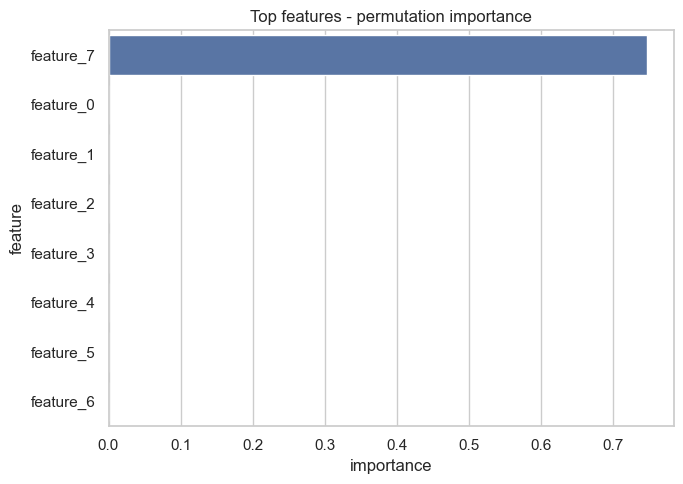

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

if TASK == "classification":
    data_sup = df.dropna(subset=[TARGET]).copy()
    X_sup = data_sup.drop(columns=[TARGET])
    y_sup = data_sup[TARGET].astype(str)
    X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = split_train_val_test(X_sup, y_sup, stratify=True)

    prep = build_preprocessor(data_sup, TARGET, USE_TEXT_FEATURE)
    base_pipe = Pipeline([
        ("prep", prep),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ])

    param_grid = {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
    }

    grid = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train_s, y_train_s)

    best_pipe = grid.best_estimator_
    pred_val = best_pipe.predict(X_val_s)
    pred_test = best_pipe.predict(X_test_s)

    print("Meilleurs params:", grid.best_params_)
    print("F1 val:", f1_score(y_val_s, pred_val, average="macro"))
    print("F1 test:", f1_score(y_test_s, pred_test, average="macro"))

    try:
        import shap

        X_sample = X_test_s.sample(n=min(300, len(X_test_s)), random_state=RANDOM_STATE)
        Xt_sample = best_pipe.named_steps["prep"].transform(X_sample)
        model = best_pipe.named_steps["model"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(Xt_sample)
        print("SHAP calcule avec succes (utiliser un plot SHAP dans une cellule dediee si besoin).")
    except Exception as e:
        print("SHAP non disponible, fallback permutation importance:", e)
        pi = permutation_importance(best_pipe, X_test_s, y_test_s, n_repeats=5, random_state=RANDOM_STATE, scoring="f1_macro")
        feat_names = [f"feature_{i}" for i in range(len(pi.importances_mean))]
        imp_df = pd.DataFrame({"feature": feat_names, "importance": pi.importances_mean}).sort_values("importance", ascending=False).head(15)
        display(imp_df)
        plt.figure(figsize=(7, 5))
        sns.barplot(data=imp_df, y="feature", x="importance")
        plt.title("Top features - permutation importance")
        plt.tight_layout()
        plt.show()

else:
    data_sup = df.dropna(subset=[TARGET]).copy()
    X_sup = data_sup.drop(columns=[TARGET])
    y_sup = pd.to_numeric(data_sup[TARGET], errors="coerce")
    mask = y_sup.notna()
    X_sup = X_sup.loc[mask]
    y_sup = y_sup.loc[mask]
    data_sup = data_sup.loc[mask]

    X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = split_train_val_test(X_sup, y_sup, stratify=False)

    prep = build_preprocessor(data_sup, TARGET, USE_TEXT_FEATURE)
    base_pipe = Pipeline([
        ("prep", prep),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE)),
    ])

    param_grid = {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
    }

    grid = GridSearchCV(
        estimator=base_pipe,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train_s, y_train_s)

    best_pipe = grid.best_estimator_
    pred_val = best_pipe.predict(X_val_s)
    pred_test = best_pipe.predict(X_test_s)

    print("Meilleurs params:", grid.best_params_)
    print("RMSE val:", float(np.sqrt(mean_squared_error(y_val_s, pred_val))))
    print("RMSE test:", float(np.sqrt(mean_squared_error(y_test_s, pred_test))))

    try:
        import shap

        X_sample = X_test_s.sample(n=min(300, len(X_test_s)), random_state=RANDOM_STATE)
        Xt_sample = best_pipe.named_steps["prep"].transform(X_sample)
        model = best_pipe.named_steps["model"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(Xt_sample)
        print("SHAP calcule avec succes (utiliser un plot SHAP dans une cellule dediee si besoin).")
    except Exception as e:
        print("SHAP non disponible, fallback permutation importance:", e)
        pi = permutation_importance(best_pipe, X_test_s, y_test_s, n_repeats=5, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error")
        feat_names = [f"feature_{i}" for i in range(len(pi.importances_mean))]
        imp_df = pd.DataFrame({"feature": feat_names, "importance": pi.importances_mean}).sort_values("importance", ascending=False).head(15)
        display(imp_df)
        plt.figure(figsize=(7, 5))
        sns.barplot(data=imp_df, y="feature", x="importance")
        plt.title("Top features - permutation importance")
        plt.tight_layout()
        plt.show()